In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, accuracy_score
from sklearn.datasets import load_diabetes,load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV

In [99]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [101]:
print(lr.coef_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [102]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [103]:
alpha_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

In [104]:
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, alpha_grid, cv=5)
ridge_cv.fit(X_train, y_train)
ridge_cv.best_params_

{'alpha': 0.1}

In [105]:
laso = Lasso()
laso_cv = GridSearchCV(laso, alpha_grid, cv=5)
laso_cv.fit(X_train, y_train)
laso_cv.best_params_

{'alpha': 0.1}

In [106]:
best_ridge = ridge_cv.best_estimator_
best_lasso = laso_cv.best_estimator_
ridge_pred_train = best_ridge.predict(X_train)
ridge_pred = ridge_cv.predict(X_test)
laso_pred_train = best_lasso.predict(X_train)
laso_pred = laso_cv.predict(X_test)
ridge_mse_train=mean_squared_error(y_train,ridge_pred_train)
ridge_mse=mean_squared_error(y_test,ridge_pred)
laso_mse_train=mean_squared_error(y_train,laso_pred_train)
laso_mse=mean_squared_error(y_test,laso_pred)
print(ridge_mse_train,ridge_mse,laso_mse_train,laso_mse)

2912.983541587901 2856.4868876706537 2935.25823259759 2798.193485169719


In [107]:
coef_comparision=pd.DataFrame(
    {
    "Ridge_Coef":ridge_cv.best_estimator_.coef_,
    "Lasso_Coef":laso_cv.best_estimator_.coef_
    }
)
print(((coef_comparision['Lasso_Coef'] == 0).sum()),((coef_comparision['Ridge_Coef'] == 0).sum()))
coef_comparision


3 0


,Ridge_Coef,Lasso_Coef
0,42.855670,0.000000
1,-205.494319,-152.664779
2,505.089033,552.697775
3,317.093205,303.365158
4,-108.500262,-81.365007
5,-86.236733,-0.000000
6,-190.363180,-229.255776
7,151.707086,0.000000
8,392.289319,447.919525
9,79.908177,29.642617


In [108]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
lr=LogisticRegression()
lr.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [110]:
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)


Intercept: [0.36142425]
Coefficients: [[ 1.8416563   0.11604855 -0.1547918   0.00543273 -0.0743871  -0.34630885
  -0.47931489 -0.20711105 -0.11122079 -0.02251289  0.0590639   0.93265271
   0.0940304  -0.0914276  -0.00706797 -0.06780586 -0.09509508 -0.02644827
  -0.02628767 -0.00589681  1.91021386 -0.35314278 -0.10729537 -0.03094047
  -0.13131502 -1.03444074 -1.27978192 -0.37990809 -0.35917677 -0.09721841]]


In [111]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)


In [112]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9560439560439561
Test Accuracy: 0.956140350877193


In [113]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
lr=LogisticRegression()
grid_search = GridSearchCV(lr, param_grid, cv=5)
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [114]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Hyperparameters: {'C': 100, 'penalty': 'l2'}
Best Cross-Validation Accuracy: 0.9538461538461538


In [115]:
best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.9649122807017544


In [116]:
best_C = grid_search.best_params_['C']
print("Best C from Step 2:", best_C)


Best C from Step 2: 100


In [117]:
l1_model = LogisticRegression(
    penalty='l1',
    C=best_C,
    solver='liblinear',
    max_iter=1000
)

l1_model.fit(X_train, y_train)

LogisticRegression(C=100, max_iter=1000, penalty='l1', solver='liblinear')

In [118]:
l2_model = LogisticRegression(
    penalty='l2',
    C=best_C,
    solver='liblinear',
    max_iter=1000
)

l2_model.fit(X_train, y_train)


LogisticRegression(C=100, max_iter=1000, solver='liblinear')

In [119]:
l1_coef = l1_model.coef_[0]
l2_coef = l2_model.coef_[0]

print("L1 Coefficients:\n", l1_coef)
print("\nL2 Coefficients:\n", l2_coef)

print("\nNumber of zero coefficients (L1):", np.sum(l1_coef == 0))
print("Number of zero coefficients (L2):", np.sum(l2_coef == 0))

L1 Coefficients:
 [ 7.43249799e-01 -1.08274697e-01  9.62905118e-02 -2.12745630e-03
  0.00000000e+00  4.72980317e+01 -1.20531359e+01 -1.36064711e+02
  1.97509227e+01  0.00000000e+00  0.00000000e+00  1.73000016e+00
 -5.06690537e-04 -1.97608064e-01  0.00000000e+00  0.00000000e+00
  5.01393662e+01  0.00000000e+00  1.88002836e+01  0.00000000e+00
  2.01122283e-01 -4.38788736e-01  5.84077250e-02 -2.10364783e-02
 -2.16741361e+01  7.96429033e+00 -1.45993910e+01 -2.52891654e+01
 -2.53587813e+01  0.00000000e+00]

L2 Coefficients:
 [ 5.40272741  0.26573732 -0.52651203 -0.02095479 -2.29922151 -0.2169419
 -3.56980218 -5.0110607  -2.26418385  0.36762747 -0.58036525  3.84169255
 -0.63875637 -0.10714305 -0.40591246  3.57237002  4.36577514 -0.26636925
  0.39354765  0.62630698 -0.20718582 -0.68999884  0.17661962 -0.01813087
 -4.67716843 -0.0140846  -4.46493229 -7.61271125 -6.83571871  0.57463274]

Number of zero coefficients (L1): 8
Number of zero coefficients (L2): 0


In [120]:
train_acc_l1 = accuracy_score(y_train, l1_model.predict(X_train))
test_acc_l1 = accuracy_score(y_test, l1_model.predict(X_test))

train_acc_l2 = accuracy_score(y_train, l2_model.predict(X_train))
test_acc_l2 = accuracy_score(y_test, l2_model.predict(X_test))

print("L1 Training Accuracy:", train_acc_l1)
print("L1 Test Accuracy:", test_acc_l1)
print("L2 Training Accuracy:", train_acc_l2)
print("L2 Test Accuracy:", test_acc_l2)

L1 Training Accuracy: 0.989010989010989
L1 Test Accuracy: 0.9824561403508771
L2 Training Accuracy: 0.9692307692307692
L2 Test Accuracy: 0.956140350877193


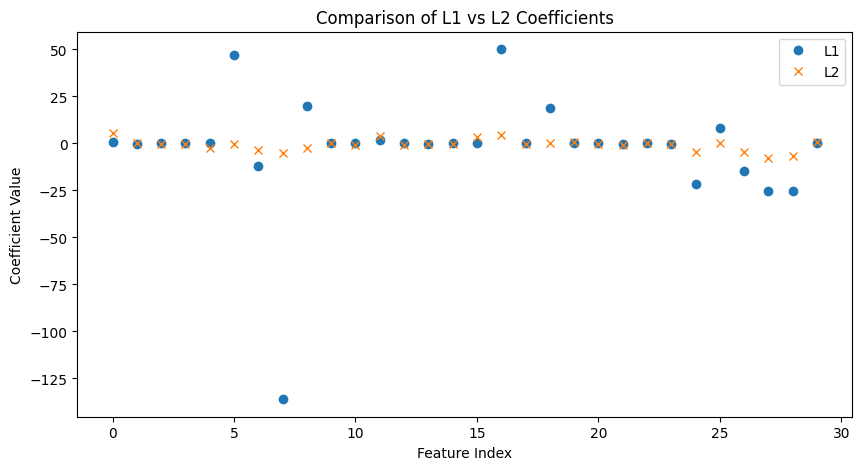

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(l1_coef, marker='o', linestyle='', label='L1')
plt.plot(l2_coef, marker='x', linestyle='', label='L2')
plt.title("Comparison of L1 vs L2 Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()

